# Pipeline Notebook for Pomelo Demand Forecasting

***Steps*** :

0. Run the first cell to import variables and create folders if necessary
1. Upload all collection templates from gdrive into that folder, e.g. temp/collection_files/62.Submission_11.07.2022
2. Check that the latest model is loaded into the same path as specified LOCAL_ONLINE_MODEL_SAVE_PATH (variable imported from config/model_config.
3. Change COLLECTION_FOLDER_NAME -> this will be  local folder you want to create in your jupyter notebook 
4. Change COLLECTION_FILE_NAME to identify date and the batch at hand.
5. Run the notebook

**Note:**
- collection_folder_name should be in this format -> `{batch no.}submission_{submission date}` e.g. 7.submission_20.05.2021
- collection_file_name will be the name of file upload to s3 should be in this format -> `batch{batch no.}_inputs_{date that file drop}` e.g. batch7_inputs_20May2021  *** no .csv needed***   

- if shreable link is https://docs.google.com/spreadsheets/d/1GJr22o4XvA2GGJswm17GUQ7WieRDJ77xkRfAcugCyX4/edit#gid=932301302 , file id will be '1GJr22o4XvA2GGJswm17GUQ7WieRDJ77xkRfAcugCyX4'


In [1]:
!pip install catboost
!pip install --upgrade google-api-python-client oauth2client
!pip install gspread
!pip install hvac
!pip install psycopg2
!pip install awswrangler

In [3]:
''' Variable Definition '''

# Change these
BATCH = "test_batch"
#COLLECTION_FOLDER_NAME = '66.Submission_09.08.2022'
COLLECTION_FOLDER_NAME = "rate_of_sales_test2"

# Check these
OUTPUT_FILE_NAME_ONLINE = f"online_output_{BATCH}.xlsx"
OUTPUT_FILE_NAME_OFFLINE = f"offline_output_{BATCH}.xlsx"
OUTPUT_FILE_NAME = f"dfm_output_{BATCH}.xlsx"
COLLECTION_FILE_NAME = f"collection_file_{BATCH}_inputs" # preprocesses collection file stores in S3
COLLECTION_FILE_DIR = f"../temp/collection_files/{COLLECTION_FOLDER_NAME}" # local dir to store collection files
MODEL_OUTPUT_DIR = "../temp/model_output/" # local directory to store model output results
COLLECTION_FILE_PATH = "s3://hal-bi-bucket/data_science/dfm/excel_files/" + COLLECTION_FILE_NAME +'.csv'

In [4]:
from catboost import CatBoostRegressor

from datetime import date, datetime

import math
import pickle
import os
import time
import sys
import warnings

import boto3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.exceptions import DataConversionWarning
from pandas.core.common import SettingWithCopyWarning
from pandas.api.types import CategoricalDtype

from os import listdir
from os.path import isfile, join

# set path to find local modules
sys.path.append("/home/ec2-user/SageMaker/ml-demand-forecasting")

from config.project_config import S3_BUCKET, STORE_CLUSTER_FILE_DEPLOY
from config.model_config import(
    FEATURES_ONLINE,
    CATEGORICAL_FEATURES_ONLINE,
    ONLINE_MODEL_NAME,
    LOCAL_ONLINE_MODEL_SAVE_PATH,
    S3_ONLINE_DATA_FILE_PATH,
    S3_ONLINE_MODEL_SAVE_PATH
)


from src.io.loaders import load_label_encoder,download_file_from_s3

from src.preprocessing.deployment_online import prep_collection_file
from src.preprocessing.deployment_online import clean_collection_input

from src.postprocessing.postprocessing_lib import drop_indonesia

from src.utils.function_lib import normal_round
from src.preprocessing.prep_sizes import change_slash_size, map_size
from src.preprocessing.data_cleaning import clean_data


from src.feature.feature_lib_online import (
    get_feature_distribution_online,
    get_historic_sales_statistics_online,
    get_size_distribution_online,
    get_historic_week_dist_feature_online
)

from src.feature.feature_lib import (
    add_collection_features,
    add_week_id,
    add_start_date_weekly,
    add_mega_campaign,
    add_price_features
)

warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)
warnings.filterwarnings(action="ignore", category=DataConversionWarning)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 10000)
pd.set_option("max_colwidth", 10000)

# Offline Imports
from config.model_config import (
    FEATURES_OFFLINE,
    CATEGORICAL_FEATURES_OFFLINE,
    LOCAL_OFFLINE_MODEL_SAVE_PATH,
    S3_OFFLINE_DATA_FILE_PATH,
    MODEL_NAME_OFFLINE,
    S3_OFFLINE_MODEL_SAVE_PATH
)

from src.feature.feature_lib import (
    get_feature_distribution,
    add_mega_campaign,
    get_historic_week_dist_feature,
    get_size_distribution,
    get_historic_sales_statistics,
    add_price_features
)

from src.preprocessing.data_cleaning import *
from src.preprocessing.prep_offline_data_deployment import *

from src.preprocessing.offline_size_dist_deploy import resize_dist
from src.preprocessing.prep_sizes import change_slash_size, map_size 

from src.postprocessing.postprocessing_lib import drop_indonesia
from src.postprocessing.adjust_channel_ratio import check_channel_raio,adjust_online_qty
from src.postprocessing.adjust_size_distribution_offline import resize_dist,get_size_dist_offline
from src.postprocessing.week_distribution import get_historic_week_dist, adjust_week_distribution
from src.postprocessing.capture_my_ratio import cdc_ratio_adjustment_online, cdc_ratio_adjustment_offline

from src.utils.function_lib import normal_round
from src.utils.pomelo_utils import Hal

from src.model.training_preparation import resample_to_cluster_level


s3 = boto3.client("s3")

# Create Folders
if not os.path.exists(COLLECTION_FILE_DIR):
    os.makedirs(COLLECTION_FILE_DIR)
    
if not os.path.exists(MODEL_OUTPUT_DIR):
    os.makedirs(MODEL_OUTPUT_DIR)
    
# local folder to store external files. E.g. traffic data
external_data_file_path = "/home/ec2-user/SageMaker/ml-demand-forecasting/temp/external_data/"
if not os.path.exists(external_data_file_path):
    os.makedirs(external_data_file_path)
    
# Local folder for client secrets to access gdrive and gsheets api.     
if not os.path.exists("/home/ec2-user/SageMaker/ml-demand-forecasting/secrets/"):
    os.makedirs("/home/ec2-user/SageMaker/ml-demand-forecasting/secrets/")
    
# Local folder to store offline model files. TO DO: replace with S3.      
if not os.path.exists(LOCAL_OFFLINE_MODEL_SAVE_PATH):
    os.makedirs(LOCAL_OFFLINE_MODEL_SAVE_PATH)

print('--------------')
print(f'Training data is loaded from: {S3_ONLINE_DATA_FILE_PATH}')
print('--------------')
print(f'Model is loaded from: {LOCAL_ONLINE_MODEL_SAVE_PATH}')
print('--------------')


/home/ec2-user/anaconda3/envs/python3/lib/python3.6/site-packages/boto3/compat.py:88: PythonDeprecationWarning: Boto3 will no longer support Python 3.6 starting May 30, 2022. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.7 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/home/ec2-user/anaconda3/envs/python3/lib/python3.6/site-packages/psycopg2/__init__.py:144: UserWarning: The psycopg2 wheel package will be renamed from release 2.8; in order to keep installing from binary please use "pip install psycopg2-binary" instead. For details see: <http://initd.org/psycopg/docs/install.html#binary-install-from-pypi>.
  """)


--------------
Training data is loaded from: s3://hal-bi-bucket/data_science/dfm/online_clothing_v2/18072022/master_join_online.parquet
--------------
Model is loaded from: /home/ec2-user/SageMaker/ml-demand-forecasting/temp/model_saves/online/18072022/model_online_18072022/catboost_model
--------------


/home/ec2-user/anaconda3/envs/python3/lib/python3.6/site-packages/boto3/compat.py:88: PythonDeprecationWarning: Boto3 will no longer support Python 3.6 starting May 30, 2022. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.7 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


In [5]:
""" Load collection files """
input_file = prep_collection_file(
    COLLECTION_FILE_DIR, COLLECTION_FILE_NAME
)
# Check that number of files in folder match unique release_collection_names in dataframe
collection_files = [f for f in listdir(COLLECTION_FILE_DIR) if ((isfile(join(COLLECTION_FILE_DIR,f))))]
#assert len(collection_files) == len(input_file.released_collection_name.unique())

# Check for duplicates in template
dup_cols = ['master_style_id', 'color', 'size_range', 'TH', 'ID', 'MY']
assert len(input_file[input_file.duplicated(dup_cols, keep = False)]) == 0


../temp/collection_files/rate_of_sales_test2/OPS_Demand Forecast Template(B_M Input_V7_8.07.2022)_Nov22_ODM2_Tribe4_Aina_CN.xlsm
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1192 entries, 0 to 1191
Columns: 132 entries, master_style_id to Unnamed: 131
dtypes: datetime64[ns](2), float64(108), object(22)
memory usage: 1.2+ MB
None
OPS_Demand Forecast Template(B_M Input_V7_8.07.2022)_Nov22_ODM2_Tribe4_Aina_CN.xlsm is finished
../temp/collection_files/rate_of_sales_test2/OPS_Demand Forecast Template(B_M Input_V7_8.07.2022)MY MELODY_Jan23.xlsm
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Columns: 132 entries, master_style_id to Unnamed: 131
dtypes: datetime64[ns](3), float64(98), int64(12), object(19)
memory usage: 11.5+ KB
None
cleaning comment in the henry id
OPS_Demand Forecast Template(B_M Input_V7_8.07.2022)MY MELODY_Jan23.xlsm is finished
../temp/collection_files/rate_of_sales_test2/OPS_Demand Forecast Template(B_M Input_V7_8.07.2022)_Graphic Tees Nov22.x

# Online Model

Catboost regression model trained on weekly sales by product-size-warehouse. The overall output will be total sales for 9 weeks but due to legacy reasons, the model is still trained on weekly level. 9-week aggregation happens at the bottom of this notebook right before saving the output file. 


### Load data and models 

In [6]:
#Online
master_join_online = pd.read_parquet(S3_ONLINE_DATA_FILE_PATH)
master_join_online = master_join_online[master_join_online.week_id <= 9]
master_join_online = master_join_online[master_join_online.year > 2019]
master_join_online = master_join_online[master_join_online.adjusted_net_units_sold <= master_join_online.adjusted_net_units_sold.quantile(0.97)]


# Offline
master_join_offline = pd.read_parquet(S3_OFFLINE_DATA_FILE_PATH)
master_join_offline.week_id = master_join_offline.week_id.str.replace('week','').astype(int)
master_join_offline['first_available_year'] = master_join_offline['first_available_date'].dt.year
master_join_offline = master_join_offline[master_join_offline.cluster.isin(['A', 'B', 'C', 'D'])]
master_join_offline = master_join_offline[master_join_offline.first_available_year > 2019]

In [7]:
# Online
download_file_from_s3(
    LOCAL_ONLINE_MODEL_SAVE_PATH,
    S3_ONLINE_MODEL_SAVE_PATH,
    S3_BUCKET
)

from_file = CatBoostRegressor()
model_online = from_file.load_model(LOCAL_ONLINE_MODEL_SAVE_PATH)


# Offline
download_file_from_s3(
    LOCAL_OFFLINE_MODEL_SAVE_PATH,
    S3_OFFLINE_MODEL_SAVE_PATH,
    S3_BUCKET
)

from_file = CatBoostRegressor()
model_offline = from_file.load_model(LOCAL_OFFLINE_MODEL_SAVE_PATH)


/home/ec2-user/anaconda3/envs/python3/lib/python3.6/site-packages/boto3/compat.py:88: PythonDeprecationWarning: Boto3 will no longer support Python 3.6 starting May 30, 2022. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.7 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


In [8]:
collection_files = [f for f in listdir(COLLECTION_FILE_DIR) if ((isfile(join(COLLECTION_FILE_DIR,f))))]
input_file.released_collection_name.unique()

array(['Nov22_ODM2_Tribe4_Aina_CN', 'My Melody_Campaign_Jan23',
       'Nov22_Graphic Tees', 'Nov_Woven_Workwear Vibes_CN_T2',
       'Nov22_ODM_Reneco_Tribe4', 'Dec_Knit(cut&sewn)_TH_T1',
       'Nov22_ODM3-2_Tribe4_Aina', 'CNY2023',
       'Harry Potter_Campaign_Dec22', 'Dec_Woven_Workwear Vibes_CN_T2',
       'Nov22_ODM1_Tribe4_Aina', 'Nov22_ODM3-1_Tribe4_Aina',
       'Dec_Woven_T2', 'Dec_Woven_Weekend Vibes_CN',
       'Dec_SustainableWoven_T1 (Cruise)'], dtype=object)

### Clean collection input

In [9]:
''' Clean Collection File '''
excel_to_db_names = {
    "number_of_styles_in_drop": "styles_in_drop",
    "category_1": "henry_category_1",
    "category_2": "henry_category_2",
    "category_3": "henry_category_3",
    "fabric": "hscode_id_fabric_name",
    "fabric_type": "fabric_custom_name",
    "sleeve_style": "sleevestyle",
        }

collection_file_online = clean_collection_input(input_file)
collection_file_online.rename(columns=excel_to_db_names, inplace = True)

ms_lookbook = [] # Add master_style_ids for large lookbook collections here
collection_file_online = add_collection_features(collection_file_online,ms_lookbook)

collection_file_online = add_week_id(collection_file_online)
collection_file_online['week_id'] = collection_file_online['week_id'].str.replace('week','').astype(int)
collection_file_online = collection_file_online[collection_file_online.week_id < 10]

collection_file_online = add_start_date_weekly(collection_file_online)
collection_file_online = add_mega_campaign(collection_file_online)

model_format_online = collection_file_online.copy()
model_format_online = clean_data(model_format_online)

/home/ec2-user/anaconda3/envs/python3/lib/python3.6/site-packages/pandas/core/arrays/datetimelike.py:1345: PerformanceWarning: Adding/subtracting object-dtype array to DatetimeArray not vectorized
  PerformanceWarning,


clean_data took: 0:00:03.322153


In [10]:
""" Data Quality Check """
# check if all forecasted categories are also in the dataframe that was used for training

unique_predict_cats_1 = model_format_online.henry_category_1.str.lower().unique()
unique_train_cats_1 = master_join_online.henry_category_1.unique()
new_cats_1 = [cat for cat in unique_predict_cats_1 if cat not in unique_train_cats_1]

unique_predict_cats_2 = model_format_online.henry_category_2.str.lower().unique()
unique_train_cats_2 = master_join_online.henry_category_2.unique()
new_cats_2 = [cat for cat in unique_predict_cats_2 if cat not in unique_train_cats_2]

unique_predict_colors = model_format_online.color.str.lower().unique()
unique_train_colors = master_join_online.color.unique()
new_colors = [col for col in unique_predict_colors if col not in unique_train_colors]

unique_predicted_sizes = model_format_online['size'].unique()
unique_train_sizes = master_join_online['size'].unique()
new_sizes = [col for col in unique_predicted_sizes if col not in unique_train_sizes]

print(f'Category 1 that were not present in training set: {new_cats_1}')
print(f'Category 2 that were not present in training set: {new_cats_2}')
print(f'Colors that were not present in training set: {new_colors}')
print(f'Sizes that were not present in training set: {new_sizes}')

Category 1 that were not present in training set: []
Category 2 that were not present in training set: ['mini', 'knee_length', 'midi', 'nan', 'maxi']
Colors that were not present in training set: []
Sizes that were not present in training set: []


### Feature engineering & prediction

In [11]:
# Calculate feature tables
feature_size_dist = get_size_distribution_online(master_join_online, 'adjusted_net_units_sold')
feature_week_dist = get_historic_week_dist_feature_online(master_join_online)
feature_dist = get_feature_distribution_online(master_join_online)
feature_sales_grp1, feature_sales_grp2, feature_sales_grp3 = get_historic_sales_statistics_online(master_join_online)

In [12]:
model_format_online = model_format_online[model_format_online.week_id.isin([1, 2, 3, 4, 5, 6, 7, 8, 9])]

model_format_online = pd.merge(
    model_format_online,
    feature_dist,
    on = ['warehouse', 'sub_product_line', 'henry_category_2', 'week_id'],
    how = 'left'
)

model_format_online = pd.merge(
    model_format_online,
    feature_sales_grp1,
    on = ['henry_category_2', 'size', 'week_id', 'warehouse'],
    how = 'left'
)

model_format_online = pd.merge(
    model_format_online,
    feature_sales_grp2,
    on = ['henry_category_2', 'size', 'week_id', 'warehouse', 'sub_product_line'],
    how = 'left'
)

model_format_online = pd.merge(
    model_format_online,
    feature_sales_grp3,
    on = ['henry_category_2', 'size', 'week_id', 'warehouse', 'sub_product_line','simple_color'],
    how = 'left'
)

model_format_online = pd.merge(
    model_format_online,
    feature_size_dist,
    on = ['henry_category_1', 'warehouse', 'size'],
    how = 'left'
)

model_format_online = pd.merge(
    model_format_online,
    feature_week_dist,
    on = ['henry_category_2', 'sub_product_line', 'warehouse', 'week_id',],
    how = 'left'
)


model_format_online.rename(columns = {'released_collection_name': 'release_collection_name' }, inplace = True)
model_format_online = add_price_features(model_format_online)
model_format_online.rename(columns = {'release_collection_name': 'released_collection_name' }, inplace = True)


model_format_online['styles_in_collection'] = model_format_online.released_collection_name.map(
    dict(model_format_online.groupby('released_collection_name').id_product.nunique())
)


feature_cols = [col for col in model_format_online.columns if col.startswith('feature_')]

In [13]:
''' Fill NAs for feature values '''
# Fill NA in grp3 sales column -> These have highest feature importance so will be filled more carefully

fill_sales_grp3_features = feature_sales_grp3.groupby(['henry_category_2', 'size', 'week_id'], as_index=False)[
    ['feature_sales_grp3_mean', 'feature_sales_grp3_max', 'feature_sales_grp3_std']
].mean()

model_format_online["fill_grp_3_key"] = model_format_online['henry_category_2'] + '-' + model_format_online['size'] + '-' +  model_format_online['week_id'].astype(str)
fill_sales_grp3_features["fill_grp_3_key"] = (
    fill_sales_grp3_features['henry_category_2'] 
    + '-' + fill_sales_grp3_features['size'] 
    + '-' +  fill_sales_grp3_features['week_id'].astype(str)
)
for col in ["feature_sales_grp3_mean", "feature_sales_grp3_max", "feature_sales_grp3_std"]:
    for k in model_format_online["fill_grp_3_key"].unique():
        model_format_online.loc[
            (model_format_online['fill_grp_3_key'] == k) & (model_format_online[col].isna()), col
        ] = fill_sales_grp3_features[fill_sales_grp3_features['fill_grp_3_key'] == k][col]
model_format_online.drop(columns = ["fill_grp_3_key"], inplace = True)


# Fill in other missing features
for col in CATEGORICAL_FEATURES_ONLINE:
    model_format_online[col].fillna('others', inplace = True)

for feat in feature_cols:
    model_format_online[feat].fillna(np.mean(model_format_online[feat]), inplace = True)
    
# fill na in week_dist
week_dist_fillna = feature_week_dist.groupby("week_id").week_dist.mean()
for week_ in model_format_online.week_id.unique():
    model_format_online.loc[(model_format_online.week_id == week_) & (model_format_online.week_dist.isna()), "week_dist"] = week_dist_fillna[week_]
    
# fill na in size dist
size_dist_fillna = feature_size_dist.groupby("size").size_dist.mean()
for s in model_format_online['size'].unique():
    model_format_online.loc[(model_format_online['size'] == s) & (model_format_online['size_dist'].isna()), "size_dist"] = size_dist_fillna[s]
    
assert (model_format_online[FEATURES_ONLINE].isna().sum().sum() == 0)

In [14]:
X = model_format_online[FEATURES_ONLINE]
X = X.reindex(FEATURES_ONLINE, axis = 1)

model_format_online['pred'] = model_online.predict(X)
model_format_online['pred'] = np.where(model_format_online['pred'] < 0, 0, model_format_online['pred'])

del X

In [15]:
''' Check for duplicates '''
dup_cols = ['master_style_id','color', 'size', 'warehouse', 'week_id']
model_format_online[model_format_online.duplicated(['master_style_id','color', 'size', 'warehouse', 'week_id'], keep = False)]

assert len(model_format_online[model_format_online.duplicated(['master_style_id','color', 'size', 'warehouse', 'week_id'], keep = False)]) == 0

### Merge predictions to collection format

In [16]:
# color in collection file have different spellings
mid_list_online = collection_file_online.copy()

mid_list_online["excel_color"] = mid_list_online['color']
mid_list_online['color'] = mid_list_online['color'].str.strip()
mid_list_online['color'] = mid_list_online['color'].str.lower()
mid_list_online['color'] = mid_list_online['color'].replace(" ", "_", regex=True)
mid_list_online['color'] = mid_list_online['color'].replace("-", "", regex=True)
mid_list_online['color'] = mid_list_online['color'].replace("/", "", regex=True)
mid_list_online['color'] = mid_list_online['color'].replace("__", "_", regex=True)  

In [17]:
# merge prediction
mid_list_online = pd.merge(
    mid_list_online,
    model_format_online[['master_style_id', 'color', 'size', 'week_id', 'warehouse', 'pred']],
    on = ['master_style_id', 'color', 'size', 'week_id', 'warehouse'],
    how = 'left',
    validate = "1:1"
)

mid_list_online.drop(columns = "color", inplace = True)
mid_list_online.rename(columns = {'excel_color': 'color'}, inplace = True)

### Drop indonesia

In [18]:
#final_list = adjust_marketing_spend_cut_my(final_list)
mid_list_online = drop_indonesia(mid_list_online)

### Analysis

In [19]:
''' Check avg predictions against historic values '''

avg_batch = np.round(
    mid_list_online.groupby(['master_style_id','color', 'warehouse']).pred.sum().mean(),2
)
avg_actual = np.round(
    master_join_online[master_join_online.year == 2022].groupby(['id_product', 'color', 'warehouse']).adjusted_net_units_sold.sum().mean(),2
)
print(f'Average sales per style of batch: {avg_batch}')
print(f'Average sales in 2022: {avg_actual}')


mid_list_agg = mid_list_online.groupby(['master_style_id','color', 'warehouse']).pred.sum().reset_index()
mid_list_agg = mid_list_agg.groupby('warehouse').pred.mean().reset_index()

mj_agg = master_join_online[master_join_online.year == 2022].groupby(['id_product', 'color', 'warehouse']).adjusted_net_units_sold.sum().reset_index()
mj_agg = mj_agg.groupby('warehouse').adjusted_net_units_sold.mean().reset_index()


mj_agg = pd.merge(
    mj_agg,
    mid_list_agg,
    on = ['warehouse'],
    how = 'left'
)
mj_agg

Average sales per style of batch: 16.62
Average sales in 2022: 14.95


,warehouse,adjusted_net_units_sold,pred
0,ID,11.539078,NaN
1,MY,9.445736,14.090723
2,TH,22.683135,19.149721


In [20]:
""" Warehouse distribution """

temp = (
    mid_list_online.groupby("warehouse")["pred"]
    .sum()
    .reset_index()
    .sort_values(by="pred", ascending=False)
    .reset_index(drop=True)
)
temp["percent_dist"] = np.round(temp["pred"] * 100 / temp["pred"].sum(), 2)
display(temp)

,warehouse,pred,percent_dist
0,TH,5017.227032,57.61
1,MY,3691.769457,42.39


Warehouse: TH
--------


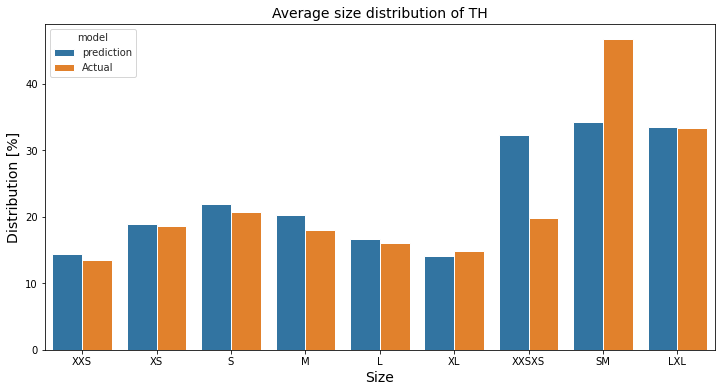

Warehouse: MY
--------


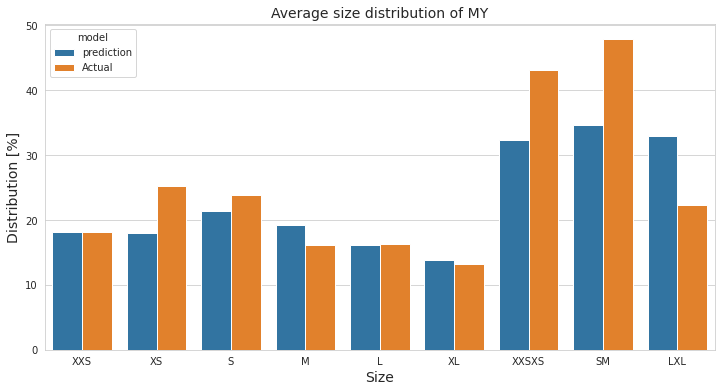

Warehouse: ID
--------


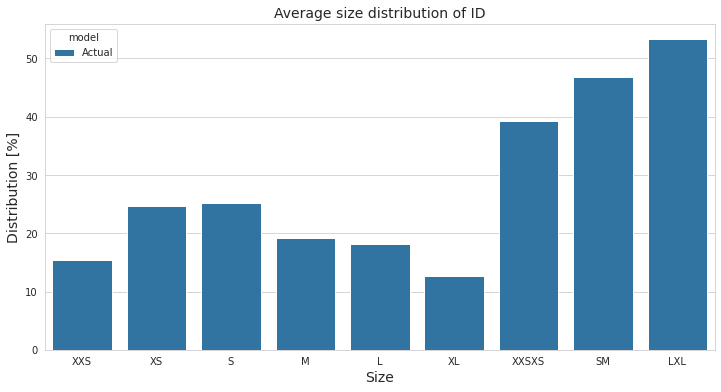

In [21]:
""" Size distribution against 2022 data """

def get_size_distribution_check(input_data, sales_column):

    total_size_dist = input_data.groupby(
        ['id_product','color', 'warehouse']
    )[sales_column].sum().reset_index()
    total_size_dist.rename(columns = {sales_column: 'total_volume'}, inplace = True)

    size_dist_data = input_data.groupby(
        ['id_product','color', 'warehouse','size', 'henry_category_1']
    )[sales_column].sum().reset_index()
    size_dist_data.rename(columns = {sales_column: 'size_volume'}, inplace = True)

    size_dist_data = pd.merge(
        size_dist_data,
        total_size_dist,
        on = ['id_product','color', 'warehouse'],
        how = 'left'
    )
    size_dist_data['size_dist'] = size_dist_data['size_volume'] / size_dist_data['total_volume']

    size_dist_data = size_dist_data.groupby(['warehouse','size', 'henry_category_1'])['size_dist'].mean().reset_index()
    
    return size_dist_data

# prepare data on to weekly aggregation
mid_list_agg = mid_list_online.groupby(
    ['id_product', 'color', 'warehouse', 'size', 'henry_category_1', 'sub_product_line']
).pred.sum().reset_index()

mj_agg = master_join_online[master_join_online.year == 2022].groupby(
    ['id_product', 'color', 'warehouse', 'size', 'henry_category_1', 'sub_product_line']
).adjusted_net_units_sold.sum().reset_index()


# Get size distributions
size_dist_test = get_size_distribution_check(mid_list_agg, 'pred')
size_dist_test['model'] = 'prediction'

size_dist_train = get_size_distribution_check(mj_agg, 'adjusted_net_units_sold')
size_dist_train['model'] = 'Actual'

size_dist_data = pd.concat([size_dist_test, size_dist_train])


average_size_dist = size_dist_data.groupby(['warehouse','size','model']).size_dist.mean().reset_index()
average_size_dist['size_dist'] = np.round(average_size_dist['size_dist'] * 100,2)

predicted_sizes = size_dist_test['size'].unique()
average_size_dist = average_size_dist[average_size_dist['size'].isin(predicted_sizes)]

size_vals = [
    'XXS', 'XS', 'S', 'M', 'L', 'XL', 'XXL',
    'XXSXS', 'SM', 'LXL',
    'XSS', 'ML', 'XLXXL',
    '25', '26', '27', '28', '30', '32', '34'
]
average_size_dist['size'] = pd.Categorical(
        average_size_dist['size'], 
        categories=size_vals,
        ordered=True)

average_size_dist.sort_values(by = 'size', inplace = True)

average_size_dist['size'] = average_size_dist['size'].astype(str)

for wh in average_size_dist.warehouse.unique():
    print(f'Warehouse: {wh}')
    print('--------')
    tmp = average_size_dist[average_size_dist.warehouse == wh]
    #display(tmp)
    
    fig, ax = plt.subplots(figsize = (12,6))
    sns.set_style('whitegrid')
    tmp = average_size_dist[average_size_dist.warehouse == wh]
    sns.barplot(data = tmp, x = tmp['size'], y = tmp.size_dist, hue = 'model')

    plt.title(f'Average size distribution of {wh}', fontsize = 14)
    plt.xlabel('Size', fontsize = 14)
    plt.ylabel('Distribution [%]', fontsize = 14)
    plt.show()
    
    
del mj_agg, mid_list_agg

### Prepare data for excel placement

### Change slash sizes

In [22]:
final_list_online = mid_list_online.copy()
slash_size_dict = {
    'XXSXS': 'XXS/XS',
    'SM': 'S/M',
    'LXL': 'L/XL',
    'XSS': 'XS/S',
    'ML': 'M/L',
    'XLXXL': 'XL/XXL',
} 

final_list_online['size'] = final_list_online['size'].replace(slash_size_dict)
print(final_list_online['size'].unique())

['XXS' 'XS' 'S' 'M' 'L' 'XL' 'XXS/XS' 'S/M' 'L/XL']


### Prepare data for order sheets

In [23]:
final_list_online["released_collection_name"] = final_list_online[
    "released_collection_name"
].str.replace(":", "")

final_list_online["released_collection_name"] = final_list_online[
    "released_collection_name"
].str.replace("[", "")

final_list_online["released_collection_name"] = final_list_online[
    "released_collection_name"
].str.replace("]", "")

print(f'Unique release collections forecasted: {final_list_online["released_collection_name"].unique()}')

# round to 2 digits
final_list_online['pred_round'] = np.round(final_list_online['pred'],2)

#rename columns
final_list_online.rename(columns = {'pred_round':'forecast'}, inplace = True)

#cast data types
final_list_online['master_style_id'] = final_list_online['master_style_id'].astype(str)
final_list_online['week_id'] = final_list_online['week_id'].astype(int)

Unique release collections forecasted: ['Nov22_ODM2_Tribe4_Aina_CN' 'My Melody_Campaign_Jan23'
 'Nov22_Graphic Tees' 'Nov_Woven_Workwear Vibes_CN_T2'
 'Nov22_ODM_Reneco_Tribe4' 'Dec_Knit(cut&sewn)_TH_T1'
 'Nov22_ODM3-2_Tribe4_Aina' 'CNY2023' 'Harry Potter_Campaign_Dec22'
 'Dec_Woven_Workwear Vibes_CN_T2' 'Nov22_ODM1_Tribe4_Aina'
 'Nov22_ODM3-1_Tribe4_Aina' 'Dec_Woven_T2' 'Dec_Woven_Weekend Vibes_CN'
 'Dec_SustainableWoven_T1 (Cruise)']


### Export to excel

In [24]:
""" Prepare data for ROS format """

#output ROS (weekly)
final_list_online = final_list_online[
    ['master_style_id','warehouse','released_collection_name','week_id','color','size','forecast', 'henry_category_1' , 'sub_product_line', 'id_product']
]

In [25]:
final_list_online.head()

,master_style_id,warehouse,released_collection_name,week_id,color,size,forecast,henry_category_1,sub_product_line,id_product
0,122485,TH,Nov22_ODM2_Tribe4_Aina_CN,1,Beige,XXS,0.70,Outerwears,Weekend,135385
1,122485,TH,Nov22_ODM2_Tribe4_Aina_CN,2,Beige,XXS,0.00,Outerwears,Weekend,135385
2,122485,TH,Nov22_ODM2_Tribe4_Aina_CN,3,Beige,XXS,0.00,Outerwears,Weekend,135385
3,122485,TH,Nov22_ODM2_Tribe4_Aina_CN,4,Beige,XXS,0.00,Outerwears,Weekend,135385
4,122485,TH,Nov22_ODM2_Tribe4_Aina_CN,5,Beige,XXS,0.55,Outerwears,Weekend,135385


In [26]:
""" Save file """

writer = pd.ExcelWriter(f'{MODEL_OUTPUT_DIR}{OUTPUT_FILE_NAME_ONLINE}', engine='xlsxwriter')

final_list_online.to_excel(writer, sheet_name='online_dfm_output',index=False) #weekly ROS
#final_list_agg.to_excel(writer, sheet_name='online_dfm_agg',index=False) #agg F9W
 
writer.save()

print(f"file saved to {MODEL_OUTPUT_DIR}{OUTPUT_FILE_NAME_ONLINE}")



file saved to ../temp/model_output/online_output_test_batch.xlsx


# Offline Model

In [35]:
input_file = pd.read_csv(COLLECTION_FILE_PATH)
prep_offline_file = prepare_input_file_offline(input_file)
#prep_offline_file.to_parquet("./prep_offline_file.parquet")

#prep_offline_file = pd.read_parquet('./prep_offline_file.parquet')

print(f'Unique sizes in drop: {prep_offline_file["size"].unique()}')

/home/ec2-user/anaconda3/envs/python3/lib/python3.6/site-packages/pandas/core/arrays/datetimelike.py:1345: PerformanceWarning: Adding/subtracting object-dtype array to DatetimeArray not vectorized
  PerformanceWarning,


prepare_input_file_offline took: 0:01:18.171788
Unique sizes in drop: ['XXS' 'XS' 'S' 'M' 'L' 'XL' 'XXSXS' 'SM' 'LXL']


In [46]:
trial_df = prep_offline_file.copy()
trial_df = add_mega_campaign(trial_df)
print(f'Dates with is_mega_campaign_order: {trial_df[trial_df.is_mega_campaign_order == 1].date_released.unique()}')

Dates with is_mega_campaign_order: ['2022-11-14T00:00:00.000000000' '2022-11-07T00:00:00.000000000'
 '2022-11-02T00:00:00.000000000' '2022-12-09T00:00:00.000000000'
 '2022-11-23T00:00:00.000000000' '2022-12-14T00:00:00.000000000'
 '2022-12-05T00:00:00.000000000' '2022-12-12T00:00:00.000000000'
 '2022-12-07T00:00:00.000000000']


In [47]:
""" Prepare data and predict sales """

columns = [
    "master_style_id",
    "id_product",
    "id_product_attribute",
    "id_shop_name",
    "product_cost_usd",
    "released_collection_name",
    "size",
    "product_line",
    "sub_product_line",
    "category_1",
    "category_2",
    "category_3",
    "color",
    "simple_color",
    "original_price_usd",
    "fabric_type",
    "fabric",
    "giveaway",
    "covid_lockdown",
    "year",
    "first_week_of_month",
    "last_week_of_month",
    "style",
    "sleeve",
    "pattern",
    "sleeve_style",
    "neckline",
    "shape",
    "rise",
    "store_cluster",
    "is_mega_campaign_order",
    "week_id",
]

mid_list_offline = trial_df[columns]

mid_list_offline = mid_list_offline.rename(
    columns={
        "category_1": "henry_category_1",
        "category_2": "henry_category_2",
        "category_3": "henry_category_3",
        "fabric": "hscode_id_fabric_name",
        "fabric_type": "fabric_custom_name",
        "sleeve_style": "sleevestyle",
        "store_cluster": "cluster",
        "year": "first_available_year"
    }
)

model_format = mid_list_offline.copy()
model_format['week_id'] = model_format['week_id'].str.replace('week','').astype(int)
model_format = clean_data(model_format)
model_format.rename(columns = {'released_collection_name': 'release_collection_name'}, inplace = True)

clean_data took: 0:00:12.133121


### Feature engineering and prediction

In [48]:
''' Add features '''
feature_dist = get_feature_distribution(master_join_offline)

In [49]:
# Resamples master join form store to average-store-cluster level. Takes some time.
# Run this once a new master_join was generated!

#master_join_resampled = resample_to_cluster_level(master_join_offline)
#master_join_resampled.to_parquet('./master_join_resampled.parquet')
master_join_resampled = pd.read_parquet('./master_join_resampled.parquet')
master_join_resampled = master_join_resampled[master_join_resampled.cluster.isin(['A', 'B', 'C', 'D'])]

#del master_join_offline

In [50]:
''' Create and add features  '''

model_format = add_price_features(model_format)

feature_sales_category, feature_sales_category2, feature_sales_cluster = get_historic_sales_statistics(master_join_resampled)

week_dist = get_historic_week_dist_feature(master_join_resampled)
week_dist.drop(columns = ["adjusted_net_units_sold", "total_sales"], axis = 1, inplace = True)

size_dist_features = get_size_distribution(master_join_resampled, 'adjusted_net_units_sold')
size_dist_features.rename(columns = {'size_dist': 'feature_size_dist'},inplace = True)

In [51]:
# Add discount, traffic and retail_dist features
model_format = pd.merge(
    model_format,
    feature_dist,
    on = ["id_shop_name",'sub_product_line','henry_category_2', "cluster", "week_id"],
    how = 'left'
)

# Sales by category
model_format = pd.merge(
    model_format,
    feature_sales_category,
    on = ['henry_category_2', 'size', 'color','week_id'],
    how = 'left'
)

# Sales by category2
model_format = pd.merge(
    model_format,
    feature_sales_category2,
    on = ['henry_category_2', 'size', 'color', 'cluster' ,'week_id'],
    how = 'left'
)

# Sales by cluster
model_format = pd.merge(
    model_format,
    feature_sales_cluster,
    on = ['henry_category_2', 'sub_product_line', 'cluster', 'size','week_id'],
    how = 'left'
)

# Size distribution
model_format = pd.merge(
    model_format,
    size_dist_features,
    on = ['id_shop_name', 'cluster', 'sub_product_line', 'size'],
    how = 'left'
)

# Week distribution
model_format = pd.merge(
    model_format,
    week_dist,
    on = ['henry_category_2', 'sub_product_line', 'cluster', 'id_shop_name', 'week_id'],
    how = 'left'
)

# Number of styles per collection feature
model_format['styles_in_collection'] = model_format.release_collection_name.map(
    dict(model_format.groupby('release_collection_name').id_product.nunique())
)

feature_cols = [col for col in model_format.columns if col.startswith('feature_')]

In [56]:
''' Fill in NA & predict '''
for col in CATEGORICAL_FEATURES_OFFLINE:
    model_format[col].fillna('others', inplace = True)
    
for feat in feature_cols:
    model_format[feat].fillna(np.mean(model_format[feat]), inplace = True)
    
# fill na in week_dist
week_dist_fillna = week_dist.groupby("week_id").week_dist.mean()
for week_ in model_format.week_id.unique():
    model_format.loc[(model_format.week_id == week_) & (model_format.week_dist.isna()), "week_dist"] = week_dist_fillna[week_]
    
assert model_format.isna().sum().sum() == 0

In [57]:
""" Prediction """

model_format['pred'] = model_offline.predict(model_format.reindex(columns = FEATURES_OFFLINE))
model_format['pred'] = np.round(model_format['pred'],2) 
model_format['pred'] = np.where(model_format['pred'] < 0, 0, model_format['pred'])

# Merge pred_round to mid_list for further processing
model_format['week_id'] = 'week' + model_format['week_id'].astype(str)

mid_list_offline = pd.merge(
    mid_list_offline,
    model_format[['id_product_attribute','size','week_id','id_shop_name','cluster','pred']],
    how = 'left',
    on = ['id_product_attribute','size','week_id','id_shop_name','cluster']
)

# Add warehouse columns
mid_list_offline["warehouse"] = np.select([
    mid_list_offline["id_shop_name"] == "TH", mid_list_offline["id_shop_name"] == "ID", mid_list_offline["id_shop_name"] == "MY", mid_list_offline["id_shop_name"] == "SG"]
    ,["TH", "ID", "MY", "MY"]
)
mid_list_offline.rename(columns={'cluster':'store_cluster'},inplace=True)

In [58]:
''' Check for duplicates '''
dup_cols = ['master_style_id','color', 'size', 'id_shop_name', 'store_cluster' , 'week_id']
mid_list_offline[mid_list_offline.duplicated(dup_cols, keep = False)]

assert len(mid_list_offline[mid_list_offline.duplicated(dup_cols, keep = False)]) == 0

### Drop indonesia

In [59]:
mid_list_offline = drop_indonesia(mid_list_offline)

### Drop impossible clusters

In [60]:
# Prediction is made for all id_shop and all cluster. However, not all combinations exist so we drop these here. 

store_cluster = pd.read_csv(STORE_CLUSTER_FILE_DEPLOY)

store_cluster_count = store_cluster.groupby(['sub_product_line','id_shop_name','cluster'])['store_name'].count().reset_index()
store_cluster_count.rename(columns={'store_name':'no_store','cluster':'store_cluster'},inplace=True)

final_list_offline = pd.merge(mid_list_offline,store_cluster_count,on =['sub_product_line','id_shop_name','store_cluster'])
# drop impossible cobination like spl='collection' - 'MY - store cluster=A'
#final_list_offline['pred_total'] = final_list_offline['pred'] * final_list_offline['no_store']

""" Filter out combinations in master join that do not exist in these collections. This makes results more comparable """
master_join_resampled['cluster_idx'] = master_join_resampled['sub_product_line'] + '-' + master_join_resampled['id_shop_name'] + '-' + master_join_resampled['cluster']
final_list_offline['cluster_idx'] = final_list_offline['sub_product_line'].str.lower() + '-' + final_list_offline['id_shop_name'] + '-' + final_list_offline['store_cluster']
master_join_resampled = master_join_resampled[master_join_resampled.cluster_idx.isin(final_list_offline.cluster_idx.unique())]
del master_join_resampled['cluster_idx']
del final_list_offline['cluster_idx']

### Analysis

In [61]:
''' Check average volume against historic values'''

test_table = final_list_offline.copy()
cluster_col = "store_cluster"
pred_col = "pred"


mj_agg = master_join_resampled[master_join_resampled.first_available_year == 2022].groupby(
    ['id_product', 'color', 'size','cluster','id_shop_name']
).adjusted_net_units_sold.sum().reset_index()

avg_sales_by_style = np.round(mj_agg.groupby(['id_product']).adjusted_net_units_sold.sum().mean(),2)
print(f'Average sales by style in 2022: {avg_sales_by_style}')

mj_agg = mj_agg.groupby(['id_product', 'cluster']).adjusted_net_units_sold.sum().reset_index()
mj_agg = mj_agg.groupby('cluster').adjusted_net_units_sold.mean().reset_index()


mid_list_agg = test_table.groupby(
    ['id_product', 'color', 'size', cluster_col,'id_shop_name']
)[pred_col].sum().reset_index()
avg_sales_predicted = np.round(mid_list_agg.groupby(['id_product'])[pred_col].sum().mean(),2)
print(f'Average sales by style predicted: {avg_sales_predicted}')

mid_list_agg = mid_list_agg.groupby([cluster_col, 'id_product'])[pred_col].sum().reset_index()
mid_list_agg = mid_list_agg.groupby(cluster_col)[pred_col].mean().reset_index()
mid_list_agg.rename(columns = {cluster_col: 'cluster'}, inplace = True)
mid_list_agg
avg_sales_by_cluster = pd.merge(
    mj_agg,
    mid_list_agg,
    on = ["cluster"],
    how = 'left'
)

avg_sales_by_cluster["percentage deviation [%]"] = (np.round(avg_sales_by_cluster[pred_col] / avg_sales_by_cluster.adjusted_net_units_sold,2) - 1) * 100
avg_sales_by_cluster


Average sales by style in 2022: 67.1
Average sales by style predicted: 67.26


,cluster,adjusted_net_units_sold,pred,percentage deviation [%]
0,A,26.574717,19.920420,-25.0
1,B,26.070901,22.254504,-15.0
2,C,20.926631,18.106985,-13.0
3,D,7.831584,6.978511,-11.0


### Change sizes

In [62]:
#final_list_online = mid_list_online.copy()
slash_size_dict = {
    'XXSXS': 'XXS/XS',
    'SM': 'S/M',
    'LXL': 'L/XL',
    'XSS': 'XS/S',
    'ML': 'M/L',
    'XLXXL': 'XL/XXL',
} 

final_list_offline['size'] = final_list_offline['size'].replace(slash_size_dict)
print(final_list_offline['size'].unique())

['XXS' 'XS' 'S' 'M' 'L' 'XL' 'XXS/XS' 'S/M' 'L/XL']


### Adjust size distribution 

In [63]:
size_dist_offline = get_size_dist_offline()
final_list_offline = resize_dist(size_dist_offline,final_list_offline.copy())

final_list_offline["pred_round"] = np.round(final_list_offline["adjusted_pred"],2)

assert final_list_offline.pred_round.isna().sum() == 0

get_size_dist_offline took: 0:00:33.193023
resize_dist took: 0:00:00.409647


### Prepare data for order sheets

In [65]:
final_list_offline["released_collection_name"] = final_list_offline[
    "released_collection_name"
].str.replace(":", "")

final_list_offline["released_collection_name"] = final_list_offline[
    "released_collection_name"
].str.replace("[", "")

final_list_offline["released_collection_name"] = final_list_offline[
    "released_collection_name"
].str.replace("]", "")

print(final_list_offline["released_collection_name"].unique())

#round up to 2 digits
final_list_offline.rename(columns = {'store_cluster':'store_grading','pred_round':'forecast'}, inplace = True)
final_list_offline['forecast'] = np.round(final_list_offline['forecast'],2)
final_list_offline['forecast_total'] = final_list_offline['forecast'] * final_list_offline['no_store']

# dtype cast
final_list_offline['master_style_id'] = final_list_offline['master_style_id'].astype(str)
final_list_offline['week_id'] = final_list_offline['week_id'].str.extract('(\d+)', expand=False)
final_list_offline['week_id'] = final_list_offline['week_id'].astype(int)

['Nov22_ODM2_Tribe4_Aina_CN' 'Nov22_ODM_Reneco_Tribe4'
 'Nov22_ODM3-2_Tribe4_Aina' 'Nov22_ODM1_Tribe4_Aina'
 'Nov22_ODM3-1_Tribe4_Aina' 'Dec_Woven_T2' 'Dec_Woven_Weekend Vibes_CN'
 'My Melody_Campaign_Jan23' 'Harry Potter_Campaign_Dec22'
 'Nov22_Graphic Tees' 'Dec_Knit(cut&sewn)_TH_T1'
 'Nov_Woven_Workwear Vibes_CN_T2' 'Dec_Woven_Workwear Vibes_CN_T2'
 'CNY2023' 'Dec_SustainableWoven_T1 (Cruise)']


In [67]:
""" Lock week distirbution to match 2022 data """

week_dist_data = get_historic_week_dist(master_join_offline, 2022)

# Match data types and spellings so that trainng data can be merged with deployment data
sub_product_line_dict = {
    'basic': 'Basic',
    'collaboration': 'Collaboration',
    'collection': 'Collection',
    'denims' : 'Denmis',
    'weekend' : 'Weekend',
    'workwear' : 'Workwear'
}
week_dist_data['sub_product_line'] = week_dist_data.sub_product_line.replace(sub_product_line_dict)
#week_dist_data.week_id = week_dist_data.week_id.str.replace('week','').astype(int)
week_dist_data.rename(columns = {'cluster': 'store_grading'}, inplace = True)

final_list_offline.henry_category_1 = final_list_offline.henry_category_1.apply(lambda x: x.lower())
final_list_offline = pd.merge(
    final_list_offline,
    week_dist_data[['henry_category_1', 'sub_product_line', 'store_grading','week_id', 'id_shop_name', 'week_dist']],
    on = ['henry_category_1', 'sub_product_line', 'store_grading', 'id_shop_name', 'week_id'],
    how = 'left'
)

# Fill na for groupby combinations that do not exist in training data 
fill_week_dist = week_dist_data.groupby('week_id').week_dist.mean().reset_index()
for week in [1,2,3,4,5,6,7]:
    final_list_offline.loc[
        final_list_offline.week_dist.isna() & (final_list_offline.week_id == week),
        'week_dist'
    ] = fill_week_dist[fill_week_dist.week_id == week].week_dist.values[0]

final_list_offline = adjust_week_distribution(final_list_offline)

In [71]:
''' Get offline aggregation over 7 weeks (only needed for analysis, no actual output) '''
final_list_offline_agg = final_list_offline.groupby([
     #"id_product_attribute",
     "id_product",
     'sub_product_line',
     'henry_category_1',
     "warehouse",
     "id_shop_name",
     "store_grading",
     "size",
     "released_collection_name",
     "master_style_id",
     "color"
]
).agg({'forecast':'sum','no_store':'mean','forecast_total':'sum'}).reset_index()
#final_list_offline_agg.rename(columns={'pred_total':'forecast_total'},inplace=True)
#final_list_offline_agg['forecast_total'] = final_list_offline_agg['forecast_total'].round(4)

assert final_list_offline_agg.duplicated(['master_style_id', 'color', 'store_grading', 'size', 'id_shop_name']).sum() == 0

In [72]:
""" Prepare data for ROS format """
# agg 7 weeks and pred_total = total qty for all store
final_list_offline_agg = final_list_offline_agg[
    ['master_style_id','color','size','store_grading','sub_product_line','id_shop_name','released_collection_name','forecast','no_store','forecast_total']
]

#output ROS (weekly)
final_list_offline = final_list_offline[
    ['master_style_id','id_product', 'color','size','store_grading','sub_product_line','week_id','id_shop_name','released_collection_name','forecast']
]

# Post Processing

Overwrites the model output in certain situations to apply a certain business logic
1. Fix MY to 15%
2. Cap online ratio at 30%

### MY adjustment

In [75]:
''' Fix MY ratio to 15 % '''
my_target_ratio = 0.15
th_target_ratio = 0.85

online_file_cap_my = cdc_ratio_adjustment_online(final_list_online,my_target_ratio,th_target_ratio)
offline_agg_2 ,final_offline_weekly  = cdc_ratio_adjustment_offline(final_list_offline,final_list_offline_agg,my_target_ratio,th_target_ratio)

"""
all file has the same column name with adjusted value
online_file ->online_file_cap_my
offline_file_agg -> offline_agg_2 
offline_file_weekly -> final_offline_weekly
"""

# rename to match the old file for check_channel_raio fn 
offline_agg_2.rename(
    columns={'forecast':'forecast_beforeadjust',
            "forecast_total":'forecast_total_beforeadjust',
            'adjust_forecast_total_cdc_store_grading':'forecast_total',
            'adjust_forecast':'forecast'},inplace=True)

before adjusting...
warehouse
MY    0.423913
TH    0.576087
Name: forecast, dtype: float64


after adjusting...
warehouse
MY    0.150049
TH    0.849951
Name: forecast, dtype: float64
before adjusting...
warehouse
MY    0.223645
TH    0.776355
Name: forecast_total, dtype: float64


/home/ec2-user/SageMaker/ml-demand-forecasting/src/postprocessing/capture_my_ratio.py:78: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  temp = offline_file_agg.groupby(['warehouse'])['forecast','forecast_total'].sum().reset_index()


,warehouse,forecast,forecast_total,forecast_cdc_dist,forecast_total_cdc_dist
0,MY,8651.43,11213.58,0.51,0.22
1,TH,8401.27,38926.52,0.49,0.78


after adjusting...
warehouse
MY    0.149994
TH    0.850006
Name: adjust_forecast_total_cdc_store_grading, dtype: float64


/home/ec2-user/SageMaker/ml-demand-forecasting/src/postprocessing/capture_my_ratio.py:113: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  temp2 = offline_agg_2.groupby(['warehouse'])['adjust_forecast','adjust_forecast_total_cdc_store_grading'].sum().reset_index()


,warehouse,adjust_forecast,adjust_forecast_total_cdc_store_grading,forecast_cdc_dist,forecast_total_cdc_dist
0,MY,5776.635802,7520.664,0.38,0.15
1,TH,9227.789880,42619.085,0.62,0.85


onverting new adjusted to weekly level...
total before adjusting dist:
15004.425681361641
total after adjusting weekly dist : 
14999.97


In [76]:
# Fill NA due to 0 total forecast
final_offline_weekly.forecast.fillna(0, inplace = True)
offline_agg_2.forecast.fillna(0, inplace = True)
offline_agg_2.forecast_total.fillna(0, inplace = True)

### Online Adjustment

Fix online volume to be 30% from offline. Request from commercials teams to ensure enough stock in online.

In [77]:
# check online ratio
target_df = check_channel_raio(
    online_file_cap_my,
    offline_agg_2,
    0.25)

total online qty 8708.48
total offline qty 50139.70
total qty 58848.18
Avg online dist for this batch : 0.15
total styles in this batch : 524
there are 391 styles need to be adjusted
total unit to adjust 6651.27


In [78]:
final_online = adjust_online_qty(online_file_cap_my,target_df,MODEL_OUTPUT_DIR,"adjusted_"+OUTPUT_FILE_NAME_ONLINE)

final_online = final_online.groupby(
    ['master_style_id', 'warehouse', 'released_collection_name', 'color', 'size', "henry_category_1", "sub_product_line", "id_product"]
)['forecast'].sum().reset_index()
final_online['forecast'] = np.round(final_online.forecast)
final_online['forecast'] = final_online['forecast'].astype(int)

if len(final_online[final_online.forecast == 0])>0:
    print('Found zero predictions. OVERWRITING...')
    final_online.loc[(final_online.forecast == 0) & (final_online['size'].isin(['XXS','XXL'])), 'forecast'] = 1
    final_online.loc[(final_online.forecast == 0) & ~(final_online['size'].isin(['XXS','XXL'])), 'forecast'] = 2

Found zero predictions. OVERWRITING...


### Analysis Online

In [79]:
''' Check avg predictions against historic values '''

avg_batch = np.round(
    final_online.groupby(['master_style_id','color', 'warehouse']).forecast.sum().mean(),2
)
avg_actual = np.round(
    master_join_online[master_join_online.year == 2022].groupby(['id_product', 'color', 'warehouse']).adjusted_net_units_sold.sum().mean(),2
)
print(f'Average sales per style of batch: {avg_batch}')
print(f'Average sales in 2022: {avg_actual}')


mid_list_agg = final_online.groupby(['master_style_id','color', 'warehouse']).forecast.sum().reset_index()
mid_list_agg = mid_list_agg.groupby('warehouse').forecast.mean().reset_index()

mj_agg = master_join_online[master_join_online.year == 2022].groupby(['id_product', 'color', 'warehouse']).adjusted_net_units_sold.sum().reset_index()
mj_agg = mj_agg.groupby('warehouse').adjusted_net_units_sold.mean().reset_index()


mj_agg = pd.merge(
    mj_agg,
    mid_list_agg,
    on = ['warehouse'],
    how = 'left'
)
mj_agg

Average sales per style of batch: 31.42
Average sales in 2022: 14.95


,warehouse,adjusted_net_units_sold,forecast
0,ID,11.539078,NaN
1,MY,9.445736,9.812977
2,TH,22.683135,53.022901


In [80]:
""" Warehouse distribution """
temp = (
    final_online.groupby("warehouse")["forecast"]
    .sum()
    .reset_index()
    .sort_values(by="forecast", ascending=False)
    .reset_index(drop=True)
)
temp["percent_dist"] = np.round(temp["forecast"] * 100 / temp["forecast"].sum(), 2)
display(temp)

,warehouse,forecast,percent_dist
0,TH,13892,84.38
1,MY,2571,15.62


Warehouse: TH
--------


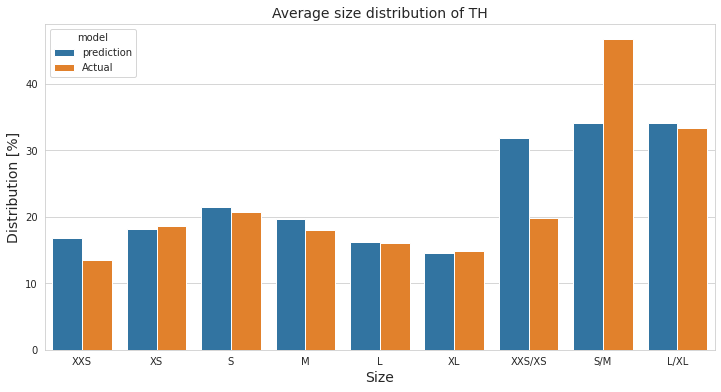

Warehouse: MY
--------


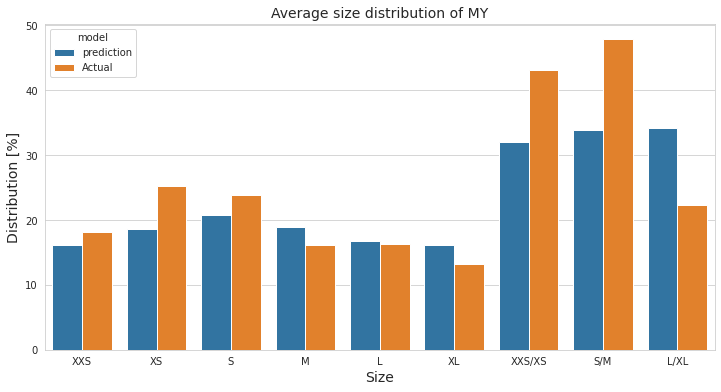

Warehouse: ID
--------


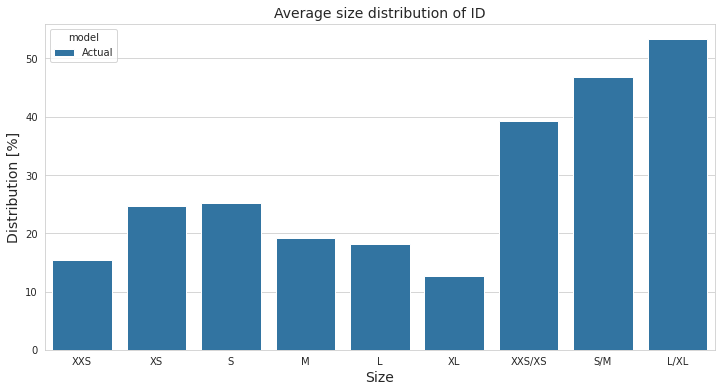

In [81]:
""" Size distribution against 2022 data """

def get_size_distribution_check(input_data, sales_column):

    total_size_dist = input_data.groupby(
        ['id_product','color', 'warehouse']
    )[sales_column].sum().reset_index()
    total_size_dist.rename(columns = {sales_column: 'total_volume'}, inplace = True)

    size_dist_data = input_data.groupby(
        ['id_product','color', 'warehouse','size', 'henry_category_1']
    )[sales_column].sum().reset_index()
    size_dist_data.rename(columns = {sales_column: 'size_volume'}, inplace = True)

    size_dist_data = pd.merge(
        size_dist_data,
        total_size_dist,
        on = ['id_product','color', 'warehouse'],
        how = 'left'
    )
    size_dist_data['size_dist'] = size_dist_data['size_volume'] / size_dist_data['total_volume']

    size_dist_data = size_dist_data.groupby(['warehouse','size', 'henry_category_1'])['size_dist'].mean().reset_index()
    
    return size_dist_data

# prepare data on to weekly aggregation
mid_list_agg = final_online.groupby(
    ['id_product', 'color', 'warehouse', 'size', 'henry_category_1', 'sub_product_line']
).forecast.sum().reset_index()


slash_size_dict = {
    'XXSXS': 'XXS/XS',
    'SM': 'S/M',
    'LXL': 'L/XL',
    'XSS': 'XS/S',
    'ML': 'M/L',
    'XLXXL': 'XL/XXL',
} 

mj_agg = master_join_online[master_join_online.year == 2022].groupby(
    ['id_product', 'color', 'warehouse', 'size', 'henry_category_1', 'sub_product_line']
).adjusted_net_units_sold.sum().reset_index()
mj_agg['size'] = mj_agg['size'].replace(slash_size_dict)

# Get size distributions
size_dist_test = get_size_distribution_check(mid_list_agg, 'forecast')
size_dist_test['model'] = 'prediction'

size_dist_train = get_size_distribution_check(mj_agg, 'adjusted_net_units_sold')
size_dist_train['model'] = 'Actual'

size_dist_data = pd.concat([size_dist_test, size_dist_train])


average_size_dist = size_dist_data.groupby(['warehouse','size','model']).size_dist.mean().reset_index()
average_size_dist['size_dist'] = np.round(average_size_dist['size_dist'] * 100,2)

predicted_sizes = size_dist_test['size'].unique()
average_size_dist = average_size_dist[average_size_dist['size'].isin(predicted_sizes)]

size_vals = [
    'XXS', 'XS', 'S', 'M', 'L', 'XL', 'XXL',
    'XXS/XS', 'S/M', 'L/XL',
    'XS/S', 'M/L', 'XL/XXL',
    '25', '26', '27', '28', '30', '32', '34'
]
average_size_dist['size'] = pd.Categorical(
        average_size_dist['size'], 
        categories=size_vals,
        ordered=True)

average_size_dist.sort_values(by = 'size', inplace = True)

average_size_dist['size'] = average_size_dist['size'].astype(str)

for wh in average_size_dist.warehouse.unique():
    print(f'Warehouse: {wh}')
    print('--------')
    tmp = average_size_dist[average_size_dist.warehouse == wh]
    #display(tmp)
    
    fig, ax = plt.subplots(figsize = (12,6))
    sns.set_style('whitegrid')
    tmp = average_size_dist[average_size_dist.warehouse == wh]
    sns.barplot(data = tmp, x = tmp['size'], y = tmp.size_dist, hue = 'model')

    plt.title(f'Average size distribution of {wh}', fontsize = 14)
    plt.xlabel('Size', fontsize = 14)
    plt.ylabel('Distribution [%]', fontsize = 14)
    plt.show()
    
    
del mj_agg, mid_list_agg

### Analysis Offline

In [82]:
''' Check average volume against historic values'''

test_table = final_offline_weekly.copy()
cluster_col = "store_grading"
pred_col = "forecast"

mj_agg = master_join_resampled[master_join_resampled.first_available_year == 2022].groupby(
    ['id_product', 'color', 'size','cluster','id_shop_name']
).adjusted_net_units_sold.sum().reset_index()

avg_sales_by_style = np.round(mj_agg.groupby(['id_product']).adjusted_net_units_sold.sum().mean(),2)
print(f'Average sales by style in 2022: {avg_sales_by_style}')

mj_agg = mj_agg.groupby(['id_product', 'cluster']).adjusted_net_units_sold.sum().reset_index()
mj_agg = mj_agg.groupby('cluster').adjusted_net_units_sold.mean().reset_index()


mid_list_agg = test_table.groupby(
    ['id_product', 'color', 'size', cluster_col,'id_shop_name']
)[pred_col].sum().reset_index()
avg_sales_predicted = np.round(mid_list_agg.groupby(['id_product'])[pred_col].sum().mean(),2)
print(f'Average sales by style predicted: {avg_sales_predicted}')

mid_list_agg = mid_list_agg.groupby([cluster_col, 'id_product'])[pred_col].sum().reset_index()
mid_list_agg = mid_list_agg.groupby(cluster_col)[pred_col].mean().reset_index()
mid_list_agg.rename(columns = {cluster_col: 'cluster'}, inplace = True)


avg_sales_by_cluster = pd.merge(
    mj_agg,
    mid_list_agg,
    on = ["cluster"],
    how = 'left'
)

avg_sales_by_cluster["percentage deviation [%]"] = (np.round(avg_sales_by_cluster[pred_col] / avg_sales_by_cluster.adjusted_net_units_sold,2) - 1) * 100
avg_sales_by_cluster


Average sales by style in 2022: 67.1
Average sales by style predicted: 57.25


,cluster,adjusted_net_units_sold,forecast,percentage deviation [%]
0,A,26.574717,18.196603,-32.0
1,B,26.070901,17.707824,-32.0
2,C,20.926631,13.523664,-35.0
3,D,7.831584,7.823702,0.0


In [84]:
''' Average sales on total forecast level '''

off_agg = offline_agg_2.groupby(['master_style_id', 'color', 'id_shop_name', 'store_grading']).forecast_total.sum().reset_index()

avg_prediction_product = off_agg.forecast_total.mean()

off_agg = off_agg.groupby(['store_grading', 'id_shop_name']).forecast_total.mean().reset_index()
#off_agg['forecast_total'] = np.round(off_agg['forecast_total'], 2)
off_agg.rename(columns = {'store_grading': 'cluster'}, inplace = True)

mj_agg = master_join_offline[master_join_offline.first_available_year == 2022]

# Sum over weeks, sizes and different stores
mj_agg = mj_agg.groupby(
    ['id_product', 'color', 'id_shop_name', 'cluster']
).adjusted_net_units_sold.sum().reset_index()

avg_sales_product = mj_agg.adjusted_net_units_sold.mean()

mj_agg = mj_agg.groupby(['cluster', 'id_shop_name']).adjusted_net_units_sold.mean().reset_index()
mj_agg['adjusted_net_units_sold'] = np.round(mj_agg['adjusted_net_units_sold'],2 )

mj_agg = pd.merge(
    mj_agg,
    off_agg,
    on = ['cluster', 'id_shop_name'],
    how = 'left'
)

print(f'Average sales predicted per style: {np.round(avg_prediction_product,2)}')
print(f'Average sales per style in 2022: {np.round(avg_sales_product,2)}')

mj_agg['percentage deviation'] = (((mj_agg.forecast_total / mj_agg.adjusted_net_units_sold) - 1 ) * 100).round(1)
mj_agg = mj_agg[mj_agg.id_shop_name != 'ID']
mj_agg.dropna(inplace = True)
mj_agg

Average sales predicted per style: 27.34
Average sales per style in 2022: 31.72


,cluster,id_shop_name,adjusted_net_units_sold,forecast_total,percentage deviation
1,A,SG,16.13,11.321059,-29.8
2,A,TH,57.36,40.206997,-29.9
5,B,SG,18.94,12.286449,-35.1
6,B,TH,49.95,41.496615,-16.9
8,C,MY,12.03,3.883820,-67.7
9,C,SG,17.61,12.053144,-31.6
10,C,TH,39.35,44.208456,12.3
12,D,MY,10.65,9.674338,-9.2
13,D,TH,20.48,36.756196,79.5


In [85]:
""" Check CDC split """
temp = (
    offline_agg_2.groupby("warehouse")["forecast_total"]
    .sum()
    .reset_index()
    .sort_values(by="forecast_total", ascending=False)
    .reset_index(drop=True)
)
temp["percent_dist"] = np.round(temp["forecast_total"] * 100 / temp["forecast_total"].sum(), 2)
display(temp)

,warehouse,forecast_total,percent_dist
0,TH,42619.085,85.0
1,MY,7520.664,15.0


Warehouse: SG
--------


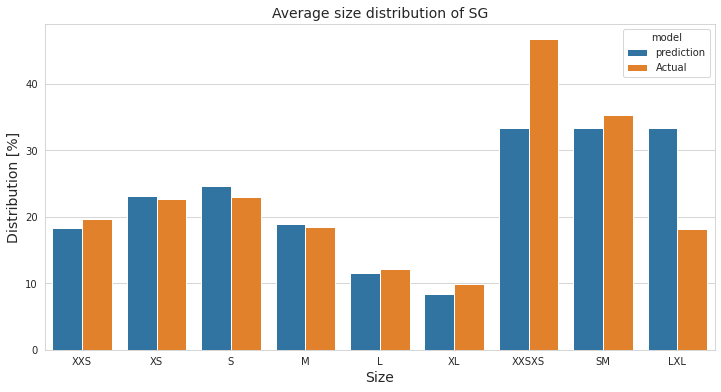

Warehouse: TH
--------


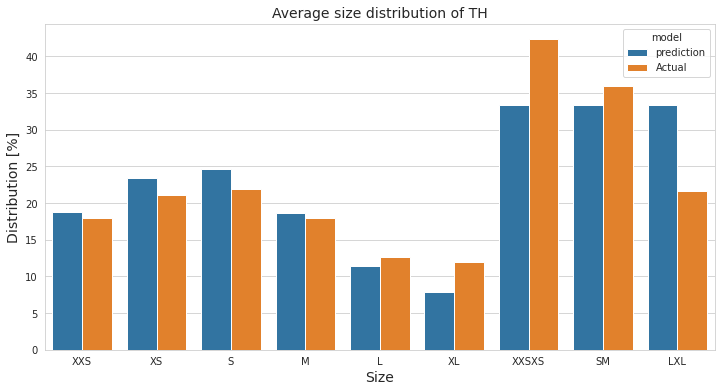

Warehouse: MY
--------


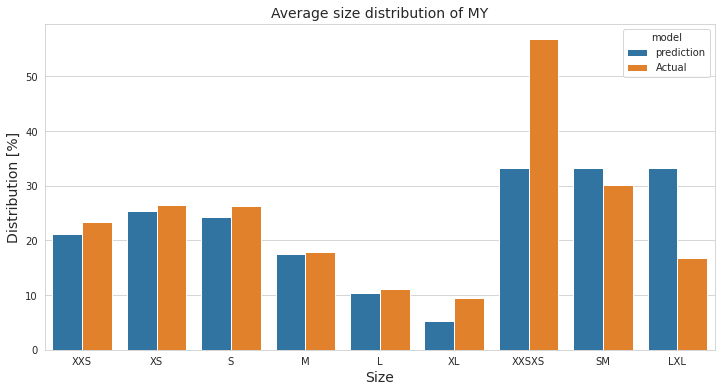

In [86]:
""" Size distribution against 2022 data """

# prepare some columns for plotting
master_join_resampled['year'] = master_join_resampled.date_released.dt.year
final_offline_weekly = pd.merge(
    final_offline_weekly,
    input_file[['id_product', 'category_1']].drop_duplicates(),
    on = ['id_product'],
    how = 'left'
)
final_offline_weekly['henry_category_1'] = final_offline_weekly['category_1']
inv_slash_size_dict = {v: k for k, v in slash_size_dict.items()}

def get_size_distribution_check(input_data, sales_column):

    total_size_dist = input_data.groupby(
        ['id_product','color', 'id_shop_name']
    )[sales_column].sum().reset_index()
    total_size_dist.rename(columns = {sales_column: 'total_volume'}, inplace = True)

    size_dist_data = input_data.groupby(
        ['id_product','color', 'id_shop_name','size', 'henry_category_1']
    )[sales_column].sum().reset_index()
    size_dist_data.rename(columns = {sales_column: 'size_volume'}, inplace = True)

    size_dist_data = pd.merge(
        size_dist_data,
        total_size_dist,
        on = ['id_product','color', 'id_shop_name'],
        how = 'left'
    )
    size_dist_data['size_dist'] = size_dist_data['size_volume'] / size_dist_data['total_volume']

    size_dist_data = size_dist_data.groupby(['id_shop_name','size', 'henry_category_1'])['size_dist'].mean().reset_index()
    
    return size_dist_data

# prepare data on to weekly aggregation
mid_list_agg = final_offline_weekly.groupby(
    ['id_product', 'color', 'id_shop_name', 'size', 'henry_category_1', 'sub_product_line']
).forecast.sum().reset_index()
mid_list_agg['size'] = mid_list_agg['size'].replace(inv_slash_size_dict)

mj_agg = master_join_resampled[master_join_resampled.year == 2022].groupby(
    ['id_product', 'color', 'id_shop_name', 'size', 'henry_category_1', 'sub_product_line']
).adjusted_net_units_sold.sum().reset_index()


# Get size distributions
size_dist_test = get_size_distribution_check(mid_list_agg, 'forecast')
size_dist_test['model'] = 'prediction'

size_dist_train = get_size_distribution_check(mj_agg, 'adjusted_net_units_sold')
size_dist_train['model'] = 'Actual'

size_dist_data = pd.concat([size_dist_test, size_dist_train])


average_size_dist = size_dist_data.groupby(['id_shop_name','size','model']).size_dist.mean().reset_index()
average_size_dist['size_dist'] = np.round(average_size_dist['size_dist'] * 100,2)

predicted_sizes = size_dist_test['size'].unique()
average_size_dist = average_size_dist[average_size_dist['size'].isin(predicted_sizes)]

size_vals = [
    'XXS', 'XS', 'S', 'M', 'L', 'XL', 'XXL',
    'XXSXS', 'SM', 'LXL',
    'XSS', 'ML', 'XLXXL',
    '25', '26', '27', '28', '30', '32', '34'
]
average_size_dist['size'] = pd.Categorical(
        average_size_dist['size'], 
        categories=size_vals,
        ordered=True)

average_size_dist.sort_values(by = 'size', inplace = True)

average_size_dist['size'] = average_size_dist['size'].astype(str)

for wh in average_size_dist.id_shop_name.unique():
    print(f'Warehouse: {wh}')
    print('--------')
    tmp = average_size_dist[average_size_dist.id_shop_name == wh]
    #display(tmp)
    
    fig, ax = plt.subplots(figsize = (12,6))
    sns.set_style('whitegrid')
    tmp = average_size_dist[average_size_dist.id_shop_name == wh]
    sns.barplot(data = tmp, x = tmp['size'], y = tmp.size_dist, hue = 'model')

    plt.title(f'Average size distribution of {wh}', fontsize = 14)
    plt.xlabel('Size', fontsize = 14)
    plt.ylabel('Distribution [%]', fontsize = 14)
    plt.show()
    
    
del mj_agg, mid_list_agg

# Save File

In [87]:
# Save file
writer = pd.ExcelWriter(
    MODEL_OUTPUT_DIR + OUTPUT_FILE_NAME, engine="xlsxwriter"
)
final_online_cols = [
    'master_style_id', 'warehouse', 'released_collection_name', 'color', 'size', 'forecast'
]
final_offline_weekly_cols = [
    'master_style_id', 'color', 'size', 'store_grading', 'sub_product_line', 'id_shop_name',
    'released_collection_name', 'warehouse', 'week_id', 'forecast'
]

final_online[final_online_cols].to_excel(writer, sheet_name="online_dfm_output", index=False)
final_offline_weekly[final_offline_weekly_cols].to_excel(writer, sheet_name="offline_dfm_output", index=False)
offline_agg_2.to_excel(writer, sheet_name="offline_dfm_agg", index=False)

writer.save()
print(f"file saved to {MODEL_OUTPUT_DIR}{OUTPUT_FILE_NAME}")

file saved to ../temp/model_output/dfm_output_test_batch.xlsx
